---
tags: [algorithm, primitive, resource-estimation]
---

# Introduction to the Quantum Phase Estimation (QPE)

Quantum Phase Estimation (QPE) estimates the eigenphase $\phi$ of a unitary
$U$ from an eigenstate $|\psi\rangle$ satisfying
$U|\psi\rangle = e^{2\pi i \phi}|\psi\rangle$. It is a central primitive in
Shor's algorithm and other algorithms that use phases encoded by unitary
eigenvalues {cite:p}`10.48550/arXiv.quant-ph/9511026,10.1098/rspa.1998.0164`.

This notebook applies the built-in `qpe` helper to a 4x4 unitary. You will
prepare a known eigenstate, run the circuit on a local Qiskit simulator,
compare the decoded phase with the known eigenphase, see how additional
counting qubits improve precision, and use resource estimation to see how the
cost grows with the requested precision.

In [1]:
# Install the latest Qamomile through pip!
# !pip install qamomile

In [2]:
# Import numerical, plotting, simulator, and Qamomile utilities.
import math
import os

import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer import AerSimulator

import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

# Decompose composite gates so the example exposes the QPE circuit structure.
transpiler = QiskitTranspiler(use_native_composite=False)

## Background: Phase Kickback and Quantum Fourier Transform

QPE combines two ideas: phase kickback from controlled unitaries
{cite:p}`10.1098/rspa.1998.0164` and the Quantum Fourier Transform
{cite:p}`10.48550/arXiv.quant-ph/0201067`.

### Phase Kickback

Phase kickback moves an eigenphase of the target register onto a control
register. Suppose

$$
U|\psi\rangle = e^{2\pi i\phi}|\psi\rangle.
$$

Put one control qubit in superposition and keep the target in $|\psi\rangle$:

$$
\frac{|0\rangle + |1\rangle}{\sqrt{2}}|\psi\rangle.
$$

A controlled-$U$ applies $U$ only on the $|1\rangle$ branch of the control.
Because the target is an eigenstate, that branch picks up the eigenphase:

$$
\frac{|0\rangle|\psi\rangle + |1\rangle U|\psi\rangle}{\sqrt{2}}
=
\frac{|0\rangle + e^{2\pi i\phi}|1\rangle}{\sqrt{2}}|\psi\rangle.
$$

The target returns to the same eigenstate, while the control carries the
phase. QPE repeats this idea with controlled powers. A controlled-$U^{2^k}$
gate kicks back the phase $e^{2\pi i 2^k\phi}$, so different control qubits
receive different binary weights of the same eigenphase. QPE keeps these
kicked-back phases coherent instead of measuring each control qubit
separately.

### Quantum Fourier Transform

The QFT on $M=2^m$ basis states is

$$
\mathrm{QFT}_M|x\rangle
= \frac{1}{\sqrt{M}}
  \sum_{y=0}^{M-1} e^{2\pi i xy/M}|y\rangle.
$$

It maps an integer $x$ to a regular phase pattern across the computational
basis. See the QFT tutorial for details. The inverse QFT performs the reverse
operation. If $\phi=a/M$ is exactly representable with $m$ bits, then the
controlled powers $U^{2^0}, U^{2^1}, \ldots, U^{2^{m-1}}$ prepare the
counting register as

$$
\frac{1}{\sqrt{M}}\sum_{k=0}^{M-1} e^{2\pi i a k/M}|k\rangle
= \mathrm{QFT}_M|a\rangle.
$$

Applying $\mathrm{QFT}_M^{-1}$ then returns $|a\rangle$. The important point
is that the inverse QFT turns phase information into a computational-basis bit
string.

$$
\underbrace{
\frac{1}{\sqrt{M}}
\begin{pmatrix}
1 \\
e^{2\pi i a/M} \\
\vdots \\
e^{2\pi i a(M-1)/M}
\end{pmatrix}
}_{\text{vector of phase values}}
\xrightarrow{\mathrm{QFT}_M^{-1}}
\underbrace{|a\rangle = |a_{m-1}\cdots a_0\rangle}_{\text{computational-basis bit string}}.
$$

## Algorithm

QPE turns the single-control phase-kickback idea into a register-wide
procedure. The counting register first stores all binary weights in
superposition. Controlled powers of $U$ then kick the corresponding weighted
eigenphases onto that register. The inverse QFT reads this Fourier-encoded
phase pattern as an ordinary binary integer, which gives an estimate of
$\phi$.

Suppose the target-register input is an eigenstate $|\psi\rangle$ of $U$,
so that $U|\psi\rangle = e^{2\pi i\phi}|\psi\rangle$, and we want $m$ bits
of precision. The counting register starts in $|0\rangle^{\otimes m}$.
Let $M=2^m$.

:::{note} Superpositions of Eigenstates
More generally, the target-register input does not have to be a single
eigenstate. If it is a superposition of eigenstates, QPE measures one of the
corresponding eigenphases with probability determined by that eigenstate's
weight in the input state. This tutorial uses one known eigenstate so the
phase-kickback algebra and sampled output are easy to read.
:::

### Step 1: Put the counting register in superposition

Apply Hadamard gates to the counting register. This creates a uniform
superposition over the $M$ possible counting-register values.

$$
|\Psi_1\rangle =
H^{\otimes m}|0\rangle^{\otimes m}|\psi\rangle
=
\frac{1}{\sqrt{M}}\sum_{r=0}^{M-1}|r\rangle|\psi\rangle.
$$

### Step 2: Apply controlled powers

For each counting qubit $k$, apply controlled-$U^{2^k}$. If
$r=\sum_{k=0}^{m-1} r_k2^k$, the target eigenstate picks up the phase
$e^{2\pi i\phi r}$:

$$
|\Psi_2\rangle =
\frac{1}{\sqrt{M}}\sum_{r=0}^{M-1}
e^{2\pi i \phi r}|r\rangle|\psi\rangle.
$$

### Step 3: Decode with inverse QFT

If $\phi=a/M$ is exactly representable, the counting register is
$\mathrm{QFT}_M|a\rangle$. Applying the inverse QFT returns $|a\rangle$.

$$
|\Psi_2\rangle =
\left(
  \frac{1}{\sqrt{M}}\sum_{r=0}^{M-1} e^{2\pi i ar/M}|r\rangle
\right)|\psi\rangle
=
\mathrm{QFT}_M|a\rangle|\psi\rangle,
$$

$$
|\Psi_3\rangle =
\mathrm{QFT}_M^{-1}\mathrm{QFT}_M|a\rangle|\psi\rangle
=
|a\rangle|\psi\rangle.
$$

### Step 4: Measure the phase

Measure the counting register. In the exact case, the measurement returns
$a$ and the phase estimate is

$$
\tilde{\phi} = \frac{a}{M}.
$$

If $\phi$ is not exactly representable with $m$ bits, the distribution
concentrates around the closest $m$-bit approximations. Increasing $m$ makes
the grid spacing $1/2^m$ smaller, so the nearest representable phase can get
closer to the true eigenphase.

:::{note} Binary Fractions and Precision
The number of fractional bits determines the phase resolution available to
QPE. For example, $\phi=0.6$ is not represented exactly on a binary grid. With
two fractional bits, the closest binary fraction is

$$
0.10_2 = \frac{1}{2^1} + \frac{0}{2^2} = 0.5
$$

With three fractional bits, the grid is finer and gives a closer value:

$$
0.101_2
= \frac{1}{2^1} + \frac{0}{2^2} + \frac{1}{2^3}
= 0.625
$$

Increasing the number of counting qubits therefore increases the number of
binary-fraction bits used to report the phase estimate.
:::

```{figure} assets/qpe_circuit.png
:alt: Quantum phase estimation circuit with a counting register, controlled powers of U, inverse QFT, and measurement.
:width: 720px

Schematic QPE circuit. The counting register controls the powers of $U$, and
the inverse QFT converts the accumulated phase pattern into measured bits.
```

## Implementation: `qpe` function

The `qmc.qpe` function applies the full QPE pattern: Hadamard gates,
controlled powers of the supplied unitary qkernel, inverse QFT, and
fixed-point phase decoding.

### Problem Example

We use a **diagonal** 4x4 unitary:

$$
U =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & e^{i\theta_{01}} & 0 & 0 \\
0 & 0 & e^{i\theta_{10}} & 0 \\
0 & 0 & 0 & e^{i\theta_{11}}
\end{pmatrix}.
$$

Every computational-basis state is an eigenstate of this matrix. We prepare
the target state $|01\rangle$ and set the phase to estimate,
$\theta_{01} / 2\pi$, to $0.6$. Because $0.6$ is not exactly representable on
a binary grid, increasing the number of counting qubits visibly improves the
approximation.

In [3]:
# Set the counting-register sizes, sampling settings, and target eigenstate.
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
COUNTING_BIT_OPTIONS = tuple(range(3, 6)) if docs_test_mode else tuple(range(3, 10))
DRAW_COUNTING_BITS = 3
EXAMPLE_COUNTING_BITS = 3
SHOTS = 512 if docs_test_mode else 4096
SAMPLER_SEED = 321
TARGET_BASIS = 1  # |01>

# Set the diagonal-unitary phases and the target phase.
TARGET_PHASE_FRACTION = 0.6
phase_fractions = np.array([0.0, TARGET_PHASE_FRACTION, 0.23, 0.81])
phase_fractions[TARGET_BASIS] = TARGET_PHASE_FRACTION
phase_angles = 2 * math.pi * phase_fractions

# Convert the phase fractions to a unitary matrix and check unitarity.
unitary = np.diag(np.exp(1j * phase_angles))
assert np.allclose(unitary.conj().T @ unitary, np.eye(4))

# Store the concrete phase parameters used by the qkernel.
PHI_01 = float(phase_angles[1])
PHI_10 = float(phase_angles[2])
PHI_11 = float(phase_angles[3])

# Print the problem instance for reference.
print("phase fractions:", np.round(phase_fractions, 6))
print("target phase fraction:", f"{TARGET_PHASE_FRACTION:.8f}")
print("U =")
print(np.round(unitary, 3))
assert 0.0 <= TARGET_PHASE_FRACTION < 1.0

phase fractions: [0.   0.6  0.23 0.81]
target phase fraction: 0.60000000
U =
[[ 1.   +0.j     0.   +0.j     0.   +0.j     0.   +0.j   ]
 [ 0.   +0.j    -0.809-0.588j  0.   +0.j     0.   +0.j   ]
 [ 0.   +0.j     0.   +0.j     0.125+0.992j  0.   +0.j   ]
 [ 0.   +0.j     0.   +0.j     0.   +0.j     0.368-0.93j ]]


### Quantum Kernel with `qpe`

First, we define the 4x4 unitary whose phase we want to estimate. The
`diagonal_4x4` qkernel implements this matrix directly. In Qamomile,
`qmc.p(q, theta)` multiplies the $|1\rangle$ component of `q` by
$e^{i\theta}$. Applying `qmc.p(q[0], phi10)` therefore gives every basis
state whose first target bit is 1 the phase $e^{i\theta_{10}}$, and
`qmc.p(q[1], phi01)` gives every basis state whose second target bit is 1
the phase $e^{i\theta_{01}}$. At that point $|11\rangle$ has accumulated
$e^{i(\theta_{10}+\theta_{01})}$, so the controlled phase gate adds only the
correction

$$
\theta_{11} - \theta_{10} - \theta_{01}
$$

on $|11\rangle$. The resulting diagonal is exactly
$\operatorname{diag}(1, e^{i\theta_{01}}, e^{i\theta_{10}},
e^{i\theta_{11}})$ in the ordered basis
$|00\rangle, |01\rangle, |10\rangle, |11\rangle$.

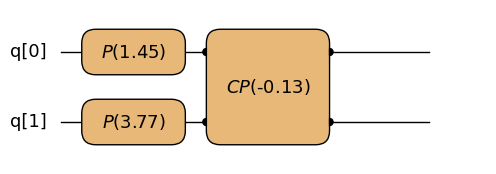

In [4]:
# Implement the diagonal 4x4 unitary with phase gates.
@qmc.qkernel
def diagonal_4x4(
    q: qmc.Vector[qmc.Qubit],
    phi01: qmc.Float,
    phi10: qmc.Float,
    phi11: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    # Add phases controlled by each target bit.
    q[0] = qmc.p(q[0], phi10)
    q[1] = qmc.p(q[1], phi01)
    # Correct the |11> entry so the full diagonal matches the matrix.
    q[0], q[1] = qmc.cp(q[0], q[1], phi11 - phi10 - phi01)
    return q


# Draw the target unitary with the concrete phase parameters.
diagonal_4x4.draw(
    q=2,
    phi01=PHI_01,
    phi10=PHI_10,
    phi11=PHI_11,
    fold_loops=False,
)

The `qmc.qpe` function returns a `QFixed` phase register. `QFixed` is
Qamomile's fixed-point number type backed by a quantum register. Here it
represents the phase fraction in $[0,1)$, and measuring it returns a
floating-point phase estimate directly. The qkernel below prepares the
eigenstate $|01\rangle$, applies QPE to `diagonal_4x4`, and measures the
decoded phase. We build it with a small factory so the number of counting
qubits can vary while the problem unitary stays the same.

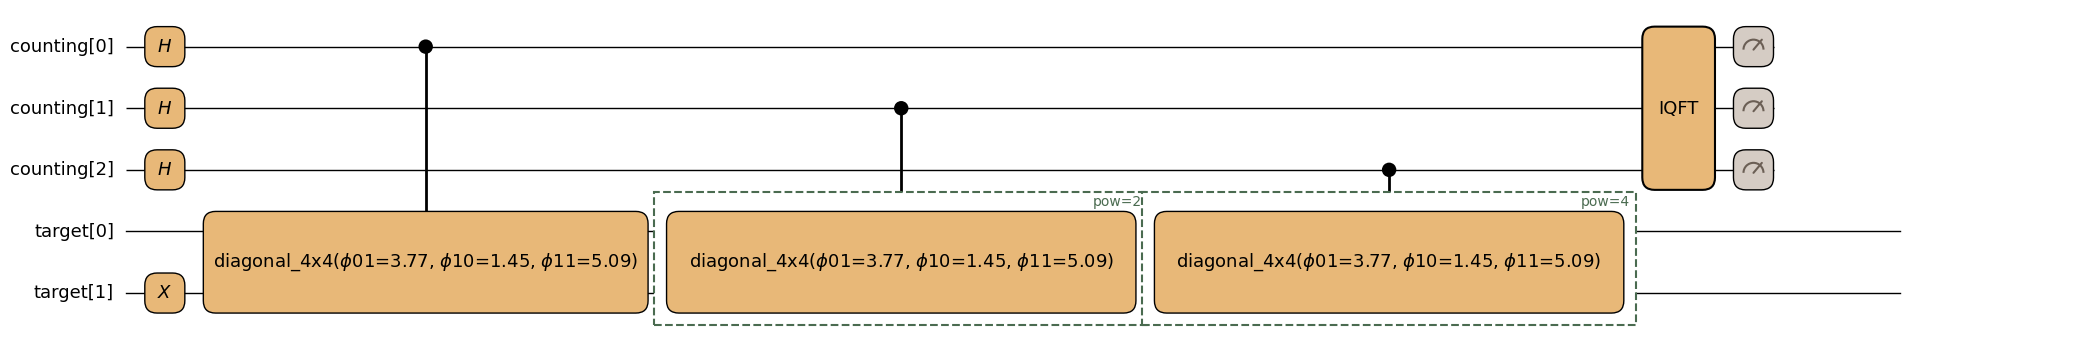

In [5]:
# Build QPE kernels parametrized by the counting-register size.
def make_qpe_kernel(counting_bits: int):
    @qmc.qkernel
    def qpe_with_stdlib(
        phi01: qmc.Float,
        phi10: qmc.Float,
        phi11: qmc.Float,
    ) -> qmc.Float:
        # Allocate the counting register and the two-qubit target register.
        counting = qmc.qubit_array(counting_bits, name="counting")
        target = qmc.qubit_array(2, name="target")
        # Prepare |01> as the target eigenstate.
        target[1] = qmc.x(target[1])

        # Apply stdlib QPE and measure the decoded fixed-point phase.
        phase = qmc.qpe(
            target,
            counting,
            diagonal_4x4,
            phi01=phi01,
            phi10=phi10,
            phi11=phi11,
        )
        return qmc.measure(phase)

    return qpe_with_stdlib


# Draw a small QPE instance used in the circuit illustration.
qpe_to_draw = make_qpe_kernel(DRAW_COUNTING_BITS)
qpe_to_draw.draw(
    phi01=PHI_01,
    phi10=PHI_10,
    phi11=PHI_11,
    fold_loops=False,
)

## Execution Result

### Circuit Transpilation and Execution

The measured `QFixed` value is returned as a floating-point phase estimate, so
no manual bit-string decoding is needed. For the first run, we use the same
three counting qubits as in the circuit drawing. The experiment prints the
`sample_result.results` entry with the largest shot count and returns only the
phase estimate used by later cells.

In [6]:
# Bind the diagonal-unitary phases at transpile time.
bindings = {"phi01": PHI_01, "phi10": PHI_10, "phi11": PHI_11}


# Compute cyclic distance between two phase fractions.
def phase_distance(a: float, b: float) -> float:
    raw_distance = abs(a - b)
    return min(raw_distance, 1.0 - raw_distance)


# Transpile and sample one QPE circuit for a chosen counting-register size.
def run_qpe_experiment(counting_bits: int) -> float:
    # Build and transpile the QPE kernel with fixed unitary phases.
    qpe_kernel = make_qpe_kernel(counting_bits)
    executable = transpiler.transpile(qpe_kernel, bindings=bindings)
    # Seed the simulator deterministically for reproducible documentation output.
    executor = transpiler.executor(
        backend=AerSimulator(
            seed_simulator=SAMPLER_SEED + counting_bits,
            max_parallel_threads=1,
        )
    )
    # Sample the measured QFixed phase estimate.
    sample_result = executable.sample(
        executor,
        shots=SHOTS,
        bindings={},
    ).result()

    # Keep the most frequently observed decoded phase.
    most_observed_result = max(sample_result.results, key=lambda item: item[1])
    print(most_observed_result)
    qpe_output, most_observed_shots = most_observed_result

    assert 0 < most_observed_shots <= SHOTS
    return qpe_output


# Run the three-counting-qubit example and verify the expected grid accuracy.
example_phase = run_qpe_experiment(EXAMPLE_COUNTING_BITS)
assert phase_distance(example_phase, TARGET_PHASE_FRACTION) <= (
    1 / 2**EXAMPLE_COUNTING_BITS
)

(0.625, 3607)


### Counting Register Size and Precision

Because the target phase $0.6$ is not exactly representable with only a few
bits, QPE returns a distribution over nearby grid points. We now vary the
number of counting qubits from 3 to 9 and compare the final `qpe` output with
the exact phase fraction. The printed rows are the most observed
`sample_result.results` entry for each counting-register size.

(0.625, 3607)
(0.625, 2379)
(0.59375, 3555)


(0.59375, 2365)


(0.6015625, 3588)
(0.6015625, 2333)


(0.599609375, 3604)


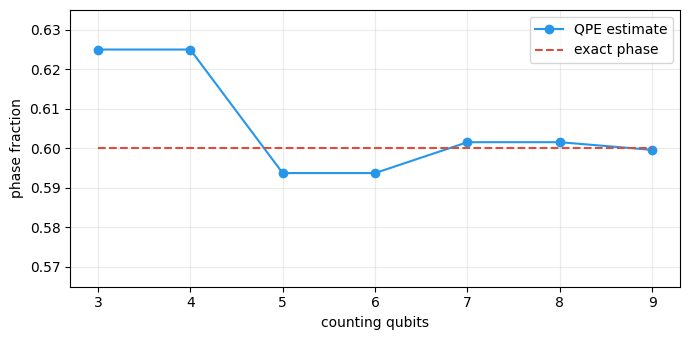

In [7]:
# Run QPE for all requested counting-register sizes.
bits = list(COUNTING_BIT_OPTIONS)
estimated_phases = [run_qpe_experiment(counting_bits) for counting_bits in bits]
# Compare estimates with the exact phase and compute wraparound errors.
exact_phases = [TARGET_PHASE_FRACTION for _ in bits]
phase_errors = [
    phase_distance(estimated_phase, TARGET_PHASE_FRACTION)
    for estimated_phase in estimated_phases
]

# Plot the phase estimates against the exact phase.
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(bits, estimated_phases, marker="o", color="#2696EB", label="QPE estimate")
ax.plot(bits, exact_phases, linestyle="--", color="#DB4D3F", label="exact phase")
ax.set_xlabel("counting qubits")
ax.set_ylabel("phase fraction")
ax.set_xticks(bits)
phase_margin = max(0.02, max(phase_errors) + 0.01)
ax.set_ylim(
    max(0.0, TARGET_PHASE_FRACTION - phase_margin),
    min(1.0, TARGET_PHASE_FRACTION + phase_margin),
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Check that additional counting qubits improve the estimate in this example.
assert phase_errors[-1] < phase_errors[0]
for counting_bits, phase_error in zip(bits, phase_errors):
    assert phase_error <= 1 / 2**counting_bits

## Resource Estimation

The previous subsection showed that more counting qubits improve precision.
We can apply `estimate_resources()` directly to the same QPE kernels used by
`run_qpe_experiment()` above. This estimate includes the Hadamards, controlled
powers from `qmc.qpe`, inverse QFT, and final fixed-point measurement.

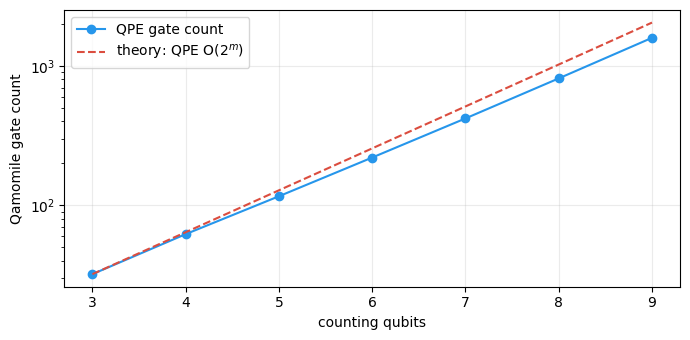

In [8]:
# Substitute concrete counting-qubit counts and collect total gate counts.
resource_gate_counts: list[int] = []
for counting_bits in bits:
    qpe_kernel = make_qpe_kernel(counting_bits)
    concrete_estimate = qpe_kernel.estimate_resources(inputs=bindings).simplify()
    resource_gate_counts.append(int(concrete_estimate.gates.total))

# Anchor a 2^m reference curve at the first resource-estimate point.
scaling_reference = [
    resource_gate_counts[0] * 2 ** (counting_bits - bits[0])
    for counting_bits in bits
]

# Plot the resource estimate with its expected exponential-in-m trend.
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(
    bits,
    resource_gate_counts,
    marker="o",
    color="#2696EB",
    label="QPE gate count",
)
ax.plot(
    bits,
    scaling_reference,
    linestyle="--",
    color="#DB4D3F",
    label=r"theory: QPE O$(2^m)$",
)
ax.set_xlabel("counting qubits")
ax.set_ylabel("total gates")
ax.set_yscale("log")
ax.set_xticks(bits)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Check that the direct estimates increase over this range.
assert all(
    later > earlier
    for earlier, later in zip(resource_gate_counts, resource_gate_counts[1:])
)

The plot shows the cost of refining the phase grid together with a reference
line proportional to $2^m$. If the target additive error is $\epsilon$, the
grid spacing should satisfy roughly

$$
2^{-m} \lesssim \epsilon,
$$

so the required number of counting qubits is

$$
m = O\!\left(\log\frac{1}{\epsilon}\right).
$$

In a repetition model for the controlled powers, QPE applies controlled
unitaries with weights $1,2,\ldots,2^{m-1}$. Therefore the number of
controlled-unitary applications is

$$
\sum_{k=0}^{m-1} 2^k = 2^m - 1
=
O\!\left(\frac{1}{\epsilon}\right).
$$

This is the main reading of the plot: logarithmically many counting qubits
in $1/\epsilon$ are enough, but the repeated controlled-unitary work scales as
$O(1/\epsilon)$ {cite:p}`10.1017/CBO9780511976667`.

Finally, this scaling depends on the implementation. QPE uses
$\mathrm{controlled}\text{-}U^{2^0}, \ldots,
\mathrm{controlled}\text{-}U^{2^{m-1}}$. If these are built by repeating $U$,
the cost is $O(2^m)=O(1/\epsilon)$, which is usually not efficient for high
precision. More generally, write the cost as

$$
G_{\mathrm{QPE}}(m)
=
\sum_{k=0}^{m-1} G\!\left(\mathrm{controlled}\text{-}U^{2^k}\right)
+ O(m^2),
$$

where $G(V)$ denotes the logical gate cost of implementing the operation $V$.
The letter $G$ is used here to make the unit of cost explicit.

:::{note} Inverse QFT Gate Count
The inverse QFT on $m$ qubits can be decomposed using $O(m^2)$ gates. Refer
to the QFT tutorial for details.
:::

In practice, however, this estimate can change significantly because of the
following factors.

1. **Controlled-unitary implementation cost.**

   The dominant cost is often the implementation of each controlled unitary.
   In Shor's algorithm, the modular-multiplication powers can be constructed
   from the problem structure, so they do not require exponentially many
   repetitions of $U$. In quantum Hamiltonian simulation, controlled
   time-evolution powers may also be implementable with polynomial resources,
   depending on the Hamiltonian model and simulation method. A useful QPE
   resource estimate should therefore state whether the controlled unitaries
   are repeated applications of $U$, directly synthesized circuits, or
   problem-specific arithmetic/simulation circuits.

2. **Initial-state preparation cost.**

   The estimate above also does not include the cost of preparing the target
   register. QPE is most useful when the input has large overlap with an
   eigenstate of $U$, or is already close to one. Preparing such an eigenstate
   or approximate eigenstate can require a nontrivial quantum circuit, and
   that cost must be counted separately in an end-to-end application.


## Summary

In this notebook, we implemented QPE on a diagonal 4x4 unitary, sampled the
decoded phase, and checked how the precision and resources change as the
counting register grows.

- `qmc.qpe` applies Hadamard gates, controlled powers, inverse QFT, and
  fixed-point phase decoding to a supplied unitary qkernel.
- The example prepares the eigenstate $|01\rangle$ and estimates the target
  phase $0.6$ directly as a floating-point `QFixed` measurement result.
- Adding counting qubits makes the binary phase grid finer, so the sampled
  estimate moves closer to the target phase.
- Direct `estimate_resources()` calls show that $m=O(\log(1/\epsilon))$
  counting qubits lead to $O(1/\epsilon)$ repeated controlled-unitary
  applications in the simple repetition model.
- In real applications, resource estimates should state how the controlled
  unitaries are implemented and whether initial-state preparation is included.